--------------------------------
<font size=5 color='cyan'> Heat Risk & Outdoor Worker Safety Intelligence Platform

-----------------------------------

## Data Pipeline: Cleaning → EDA → Feature Engineering → Risk Engine → Recommendation Engine → What-If Simulator

**FortyGuard Hackathon'26 — "Build for a Cooler Future"**

> **Important:** Risk weights in this notebook are transparent, heuristic starting weights for the hackathon prototype. They are not medical or scientifically validated thresholds.


---
##<font size=5 color='salmon'>  0. Setup

Install/import dependencies and connect to the local SQLite database (`heat_risk.db`).

In [16]:
from pathlib import Path
import sqlite3
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

BASE_DIR = Path("__file__").resolve().parent.parent
DB_PATH = BASE_DIR / "data" / "heat_risk.db"
conn = sqlite3.connect(DB_PATH)

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables in DB:")
print(tables)

Tables in DB:
              name
0  fortyguard_data
1  sqlite_sequence
2         osm_data


---
####<font size=5 color='salmon'> 1. Load Raw Data

Both `fortyguard_data` and `osm_data` store their payload as a single JSON blob per row
(one row = one API call for the whole bounding box). We load the metadata table first,
then parse the JSON out of the `data` column.

In [17]:
fortyguard_meta = pd.read_sql("SELECT * FROM fortyguard_data", conn)
osm_meta = pd.read_sql("SELECT * FROM osm_data", conn)

print("FortyGuard rows (API calls):", fortyguard_meta.shape)
print("OSM rows (API calls):", osm_meta.shape)

fortyguard_meta[["id", "fetched_at", "start_date", "end_date", "south", "west", "north", "east"]]

FortyGuard rows (API calls): (1, 9)
OSM rows (API calls): (1, 7)


,id,fetched_at,start_date,end_date,south,west,north,east
0,1,2026-08-19T15:49:39.152524,2026-08-01,2026-08-14,29.694598,-95.4899,29.779552,-95.38021


In [18]:
# Parse the JSON payloads
fg_json = json.loads(fortyguard_meta.loc[0, "data"])
osm_json = json.loads(osm_meta.loc[0, "data"])

print("FortyGuard top-level keys:", fg_json.keys())
print("OSM top-level keys:", osm_json.keys())

FortyGuard top-level keys: dict_keys(['map_data', 'stats_data'])
OSM top-level keys: dict_keys(['version', 'generator', 'osm3s', 'elements'])


In [19]:
# Check if ANY element in the raw OSM data has these tags at all
count_landuse = sum(1 for e in osm_json["elements"] if e.get("tags", {}).get("landuse") in {"forest","grass","meadow"})
count_natural_veg = sum(1 for e in osm_json["elements"] if e.get("tags", {}).get("natural") in {"wood","tree","scrub"})
count_garden = sum(1 for e in osm_json["elements"] if e.get("tags", {}).get("leisure") == "garden")
count_waterway = sum(1 for e in osm_json["elements"] if "waterway" in e.get("tags", {}))

print("landuse forest/grass/meadow:", count_landuse)
print("natural wood/tree/scrub:", count_natural_veg)
print("leisure garden:", count_garden)
print("waterway:", count_waterway)

landuse forest/grass/meadow: 3
natural wood/tree/scrub: 0
leisure garden: 1
waterway: 0


---
####<font size=5 color='salmon'> 2. Data Quality Check

Before joining anything, confirm the file loaded cleanly and inspect nulls/duplicates
at the metadata level.

In [20]:
print("=== FortyGuard metadata ===")
print(fortyguard_meta.info())
print("\nNulls:\n", fortyguard_meta.isnull().sum())
print("\nDuplicate rows:", fortyguard_meta.duplicated().sum())

print("\n=== OSM metadata ===")
print(osm_meta.info())
print("\nNulls:\n", osm_meta.isnull().sum())
print("\nDuplicate rows:", osm_meta.duplicated().sum())

=== FortyGuard metadata ===
<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          1 non-null      int64  
 1   fetched_at  1 non-null      str    
 2   start_date  1 non-null      str    
 3   end_date    1 non-null      str    
 4   south       1 non-null      float64
 5   west        1 non-null      float64
 6   north       1 non-null      float64
 7   east        1 non-null      float64
 8   data        1 non-null      str    
dtypes: float64(4), int64(1), str(4)
memory usage: 204.0 bytes
None

Nulls:
 id            0
fetched_at    0
start_date    0
end_date      0
south         0
west          0
north         0
east          0
data          0
dtype: int64

Duplicate rows: 0

=== OSM metadata ===
<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      ----------

---
## <font size=5 color='salmon'>3. Flatten FortyGuard Data (Heat Tiles)

FortyGuard returns a **GeoJSON FeatureCollection** — each feature is a grid **tile**
with `tile_id`, `average_temperature`, `min_temperature`, `max_temperature`, and a
`Polygon` geometry (tile boundary).

We flatten this into one row per tile, and compute each tile's **centroid**
(average of its polygon corner points) — this becomes the tile's representative
lat/lon for joining with OSM data later.

In [21]:
def polygon_centroid(coords):
    """coords: list of [lon, lat] pairs (first ring of a GeoJSON Polygon)"""
    ring = coords[0]  # outer ring
    lons = [pt[0] for pt in ring]
    lats = [pt[1] for pt in ring]
    return sum(lats) / len(lats), sum(lons) / len(lons)

tiles = []
for feature in fg_json["map_data"]["features"]:
    props = feature["properties"]
    geom = feature["geometry"]["coordinates"]
    centroid_lat, centroid_lon = polygon_centroid(geom)

    tiles.append({
        "tile_id": props["tile_id"],
        "avg_temp": props["average_temperature"],
        "min_temp": props["min_temperature"],
        "max_temp": props["max_temperature"],
        "centroid_lat": centroid_lat,
        "centroid_lon": centroid_lon,
        "polygon": geom,  # keep raw polygon for spatial join later
    })

fg_df = pd.DataFrame(tiles)
print("Total tiles:", fg_df.shape[0])
fg_df.head()

Total tiles: 9941


,tile_id,avg_temp,min_temp,max_temp,centroid_lat,centroid_lon,polygon
0,0,32.1751,25.6710,38.1996,29.694510,-95.394746,"[[[-95.39515099978803, 29.6941417519469], [-95..."
1,1,32.1796,25.6781,38.2208,29.694529,-95.393713,"[[[-95.39411745073788, 29.694160445729597], [-..."
2,2,32.1838,25.6849,38.2414,29.694547,-95.392679,"[[[-95.39308390071395, 29.69417913145912], [-9..."
3,3,32.1876,25.6912,38.2606,29.694566,-95.391645,"[[[-95.39205034971667, 29.694197809135474], [-..."
4,4,32.1910,25.6969,38.2780,29.694585,-95.390612,"[[[-95.39101679774643, 29.694216478758612], [-..."


In [22]:
# Quick sanity check on FortyGuard tile data
print(fg_df[["avg_temp", "min_temp", "max_temp"]].describe())
print("\nNulls per column:\n", fg_df.isnull().sum())
print("Duplicate tile_ids:", fg_df["tile_id"].duplicated().sum())

          avg_temp     min_temp     max_temp
count  9941.000000  9941.000000  9941.000000
mean     31.514418    25.377793    37.700879
std       0.638885     0.309017     0.538869
min      29.917900    24.570200    35.998800
25%      30.965500    25.301000    37.595500
50%      31.731800    25.491200    37.920000
75%      32.065000    25.598600    38.025000
max      32.431800    25.870400    38.328000

Nulls per column:
 tile_id         0
avg_temp        0
min_temp        0
max_temp        0
centroid_lat    0
centroid_lon    0
polygon         0
dtype: int64
Duplicate tile_ids: 0


---
##<font size=5 color='salmon'> 4. Flatten OpenStreetMap Data (Nodes & Ways)

The Overpass query used `out body; >; out skel qt;` — this means:
- **Nodes** come with direct `lat`/`lon` — usable immediately.
- **Ways** (buildings, roads, parks, water bodies) only reference **node IDs**
  in their geometry — we must resolve each way's shape by looking up its
  member nodes' coordinates.

We split `elements` into nodes and ways, then resolve way geometries.

In [23]:
elements = osm_json["elements"]

osm_nodes = [e for e in elements if e["type"] == "node"]
osm_ways = [e for e in elements if e["type"] == "way"]

print("Total elements:", len(elements))
print("Nodes:", len(osm_nodes))
print("Ways:", len(osm_ways))

Total elements: 597903
Nodes: 504190
Ways: 93713


In [24]:
# Nodes -> DataFrame (already have lat/lon)
nodes_df = pd.json_normalize(osm_nodes)
nodes_df = nodes_df.rename(columns={"id": "node_id"})
print(nodes_df.shape)
nodes_df.head()

(504190, 309)


,type,node_id,lat,lon,tags.amenity,tags.ele,tags.gnis:feature_id,tags.name,tags.religion,tags.isced:level,tags.check_date,tags.website,tags.addr:city,tags.addr:housenumber,tags.addr:postcode,tags.addr:state,tags.addr:street,tags.wikidata,tags.emergency,tags.healthcare,tags.old_name,tags.operator,tags.phone,tags.beds,tags.denomination,...,tags.operational_status,tags.seats:separated,tags.survey:date,tags.organic,tags.recycling:green_waste,tags.faces,tags.support,tags.visibility,tags.recycling:cardboard,tags.recycling:plastic_bottles,tags.payment:qr_code,tags.community_centre,tags.height,tags.contact:fax,tags.type,tags.contact:linkedin,tags.language:en,tags.language:es,tags.lawyer:speciality:personal_injury,tags.street_vendor,tags.check_date:diet:gluten_free,tags.check_date:diet:vegan,tags.check_date:diet:vegetarian,tags.opening_date,tags.education
0,node,151402920,29.743272,-95.412885,parking_entrance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,node,356708663,29.714397,-95.457441,place_of_worship,18,1338383,Incarnate Word Convent,christian,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,node,356709720,29.741918,-95.405087,school,17,1339624,Lanier Junior High School,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,node,356711547,29.738032,-95.389084,school,17,1341842,Montrose School,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,node,356750147,29.768561,-95.412995,school,17,1374901,Messiah School,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
# Build a lookup: node_id -> (lat, lon), so we can resolve way geometries
node_lookup = {n["id"]: (n["lat"], n["lon"]) for n in osm_nodes}

def resolve_way_points(way, node_lookup):
    """Return every (lat, lon) for a way's member nodes — used to test tile
    membership, NOT averaged into a single centroid."""
    node_ids = way.get("nodes", [])
    return [node_lookup[nid] for nid in node_ids if nid in node_lookup]

way_vertex_records = []
for w in osm_ways:
    tags = w.get("tags", {})
    pts = resolve_way_points(w, node_lookup)
    if not pts:
        continue
    for lat, lon in pts:
        way_vertex_records.append({
            "osm_id": w["id"],
            "lat": lat,
            "lon": lon,
            "tags": tags,
            "source": "way",
        })

ways_df = pd.DataFrame(way_vertex_records)
unresolved_ways = len({w["id"] for w in osm_ways}) - ways_df["osm_id"].nunique()
print("Ways resolved:", ways_df["osm_id"].nunique(), "/", len(osm_ways))
print("Ways with no resolvable nodes:", unresolved_ways)
ways_df.head()

Ways resolved: 93713 / 93713
Ways with no resolvable nodes: 0


,osm_id,lat,lon,tags,source
0,15276340,29.706202,-95.441900,"{'highway': 'service', 'service': 'parking_ais...",way
1,15276340,29.706212,-95.441276,"{'highway': 'service', 'service': 'parking_ais...",way
2,15276341,29.706699,-95.441021,"{'highway': 'service', 'surface': 'asphalt'}",way
3,15276341,29.706696,-95.441097,"{'highway': 'service', 'surface': 'asphalt'}",way
4,15276341,29.706697,-95.441209,"{'highway': 'service', 'surface': 'asphalt'}",way


In [26]:
import pandas as pd

# Build nodes_simple from osm_nodes directly to ensure 'tags' is a dictionary
nodes_simple_records = []
for n in osm_nodes:
    nodes_simple_records.append({
        "osm_id": n["id"],
        "lat": n["lat"],
        "lon": n["lon"],
        "tags": n.get("tags", {}), # Ensure tags is a dictionary, default to empty dict
        "source": "node"
    })
nodes_simple = pd.DataFrame(nodes_simple_records)
nodes_simple["source"] = "node"

ways_simple = ways_df.dropna(subset=["lat", "lon"])  # already has osm_id, lat, lon, tags, source

osm_points = pd.concat([nodes_simple, ways_simple[["osm_id", "lat", "lon", "tags", "source"]]], ignore_index=True)
print("Unified OSM points:", osm_points.shape)
osm_points.head()

Unified OSM points: (1129845, 5)


,osm_id,lat,lon,tags,source
0,151402920,29.743272,-95.412885,{'amenity': 'parking_entrance'},node
1,356708663,29.714397,-95.457441,"{'amenity': 'place_of_worship', 'ele': '18', '...",node
2,356709720,29.741918,-95.405087,"{'amenity': 'school', 'ele': '17', 'gnis:featu...",node
3,356711547,29.738032,-95.389084,"{'amenity': 'school', 'ele': '17', 'gnis:featu...",node
4,356750147,29.768561,-95.412995,"{'amenity': 'school', 'ele': '17', 'gnis:featu...",node


---
##<font size=5 color='salmon'> 5. Categorize OSM Features into Vulnerability-Relevant Groups

Raw OSM `tags` are messy free-form dicts. We extract the signals that matter for
heat vulnerability: **green cover, water bodies, buildings, shade/amenities**.

In [27]:
def classify_osm_point(tags):
    if not isinstance(tags, dict):
        return "other"
    if tags.get("natural") == "water" or tags.get("waterway"):
        return "water_body"
    if (tags.get("leisure") in {"park", "garden"}
        or tags.get("landuse") in {"forest", "grass", "meadow"}
        or tags.get("natural") in {"wood", "tree", "scrub"}):
        return "green_cover"
    if tags.get("amenity") in {"school", "hospital", "clinic", "place_of_worship", "shelter"}:
        return "shade_relevant_amenity"
    if "building" in tags:
        return "building"
    if "highway" in tags:
        return "road"
    return "other"

---
## <font size=5 color='salmon'>6. Spatial Join — Assign OSM Points to FortyGuard Tiles

Each FortyGuard tile is a small polygon. We assign every OSM point (node/way
centroid) to the tile whose polygon contains it, using a simple point-in-polygon
test (ray casting — no extra geospatial library required).

In [28]:
! pip install tqdm

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\digvi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [29]:
import numpy as np

# Step 1: precompute bounding box (min/max lat/lon) for each tile — this lets us
# skip the expensive point-in-polygon check for tiles that obviously can't contain the point
def polygon_bbox(coords):
    ring = coords[0]
    lons = [pt[0] for pt in ring]
    lats = [pt[1] for pt in ring]
    return min(lats), max(lats), min(lons), max(lons)

fg_df["bbox"] = fg_df["polygon"].apply(polygon_bbox)

def point_in_polygon(lat, lon, polygon_coords):
    ring = polygon_coords[0]
    x, y = lon, lat
    inside = False
    n = len(ring)
    j = n - 1
    for i in range(n):
        xi, yi = ring[i]
        xj, yj = ring[j]
        if ((yi > y) != (yj > y)) and (x < (xj - xi) * (y - yi) / (yj - yi + 1e-15) + xi):
            inside = not inside
        j = i
    return inside

def assign_tile_fast(lat, lon, tiles_records):
    for tile_id, polygon, (min_lat, max_lat, min_lon, max_lon) in tiles_records:
        # cheap bbox check first — skips 99% of tiles instantly
        if lat < min_lat or lat > max_lat or lon < min_lon or lon > max_lon:
            continue
        if point_in_polygon(lat, lon, polygon):
            return tile_id
    return None

# Convert tiles to a plain list ONCE (avoids repeated DataFrame overhead)
tiles_records = list(zip(fg_df["tile_id"], fg_df["polygon"], fg_df["bbox"]))

# Use .apply on a Series (faster than iterrows-based approach), still shows progress
from tqdm import tqdm
tqdm.pandas()

osm_points["tile_id"] = osm_points.progress_apply(
    lambda row: assign_tile_fast(row["lat"], row["lon"], tiles_records), axis=1
)

matched = osm_points["tile_id"].notnull().sum()
print(f"OSM points matched to a tile: {matched} / {len(osm_points)}")

100%|██████████| 1129845/1129845 [26:13<00:00, 717.89it/s] 

OSM points matched to a tile: 1102402 / 1129845


---
##<font size=5 color='salmon'> 7. Build the Master Tile-Level Table

Aggregate OSM feature counts per tile, then join with FortyGuard's temperature data.
**One row = one geographic heat tile.** This is the single table used by the feature,
risk, recommendation and simulation engines.

We keep OSM counts as contextual indicators. They should be interpreted as mapped
features from OSM, not as exact physical area measurements.


In [30]:
# Count each OSM category per tile
osm_points["category"] = osm_points["tags"].apply(classify_osm_point)
osm_counts = (
    osm_points.dropna(subset=["tile_id"])
    .drop_duplicates(subset=["osm_id", "tile_id", "category"])
    .groupby(["tile_id", "category"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Expected OSM categories
osm_cols_expected = [
    "water_body", "green_cover", "building",
    "shade_relevant_amenity", "road", "other"
]
for col in osm_cols_expected:
    if col not in osm_counts.columns:
        osm_counts[col] = 0

master_df = fg_df.merge(osm_counts, on="tile_id", how="left")
master_df[osm_cols_expected] = master_df[osm_cols_expected].fillna(0)

# Approximate tile area from the FortyGuard polygon.
# This is only used to turn raw OSM counts into comparable density indicators.
# For these small tiles, the equirectangular approximation is sufficient for a prototype.
def approx_tile_area_km2(polygon):
    ring = polygon[0]
    lons = np.array([p[0] for p in ring])
    lats = np.array([p[1] for p in ring])
    lat_mid = np.mean(lats)
    width_km = (lons.max() - lons.min()) * 111.32 * np.cos(np.radians(lat_mid))
    height_km = (lats.max() - lats.min()) * 111.32
    return max(width_km * height_km, 1e-6)

master_df["tile_area_km2"] = master_df["polygon"].apply(approx_tile_area_km2)
master_df["osm_feature_count"] = master_df[osm_cols_expected].sum(axis=1)
master_df["osm_match_flag"] = (master_df["osm_feature_count"] > 0).astype(int)

print("Master table shape:", master_df.shape)
print("OSM-covered tiles:", master_df["osm_match_flag"].sum(), "/", len(master_df))
print("Approx tile area (km²):", master_df["tile_area_km2"].median())
master_df.head()


Master table shape: (9941, 17)
OSM-covered tiles: 9786 / 9941
Approx tile area (km²): 0.010457268194223322


,tile_id,avg_temp,min_temp,max_temp,centroid_lat,centroid_lon,polygon,bbox,building,green_cover,other,road,shade_relevant_amenity,water_body,tile_area_km2,osm_feature_count,osm_match_flag
0,0,32.1751,25.6710,38.1996,29.694510,-95.394746,"[[[-95.39515099978803, 29.6941417519469], [-95...","(29.6941417519469, 29.695061976325974, -95.395...",3.0,0.0,33.0,8.0,0.0,0.0,0.01045,44.0,1
1,1,32.1796,25.6781,38.2208,29.694529,-95.393713,"[[[-95.39411745073788, 29.694160445729597], [-...","(29.694160445729597, 29.695080662735368, -95.3...",3.0,0.0,13.0,0.0,0.0,0.0,0.01045,16.0,1
2,2,32.1838,25.6849,38.2414,29.694547,-95.392679,"[[[-95.39308390071395, 29.69417913145912], [-9...","(29.69417913145912, 29.695099341091286, -95.39...",2.0,0.0,18.0,4.0,0.0,0.0,0.01045,24.0,1
3,3,32.1876,25.6912,38.2606,29.694566,-95.391645,"[[[-95.39205034971667, 29.694197809135474], [-...","(29.694197809135474, 29.69511801139369, -95.39...",16.0,0.0,75.0,5.0,0.0,0.0,0.01045,96.0,1
4,4,32.1910,25.6969,38.2780,29.694585,-95.390612,"[[[-95.39101679774643, 29.694216478758612], [-...","(29.694216478758612, 29.69513667364257, -95.39...",15.0,0.0,72.0,4.0,0.0,0.0,0.01045,91.0,1


---
##<font size=5 color='salmon'> 8. Exploratory Data Analysis (EDA)

Find trends and patterns before building the scoring model

In [32]:
master_df[["avg_temp", "min_temp", "max_temp"] + osm_cols_expected].describe()

,avg_temp,min_temp,max_temp,water_body,green_cover,building,shade_relevant_amenity,road,other
count,9941.000000,9941.000000,9941.000000,9941.000000,9941.000000,9941.000000,9941.000000,9941.000000,9941.000000
mean,31.514418,25.377793,37.700879,0.054220,0.080374,7.991953,0.066291,6.503772,49.707474
std,0.638885,0.309017,0.538869,0.242757,0.316987,7.589449,0.286749,6.820161,32.556052
min,29.917900,24.570200,35.998800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.965500,25.301000,37.595500,0.000000,0.000000,2.000000,0.000000,2.000000,25.000000
50%,31.731800,25.491200,37.920000,0.000000,0.000000,6.000000,0.000000,4.000000,45.000000
75%,32.065000,25.598600,38.025000,0.000000,0.000000,13.000000,0.000000,9.000000,70.000000
max,32.431800,25.870400,38.328000,3.000000,5.000000,56.000000,4.000000,64.000000,235.000000


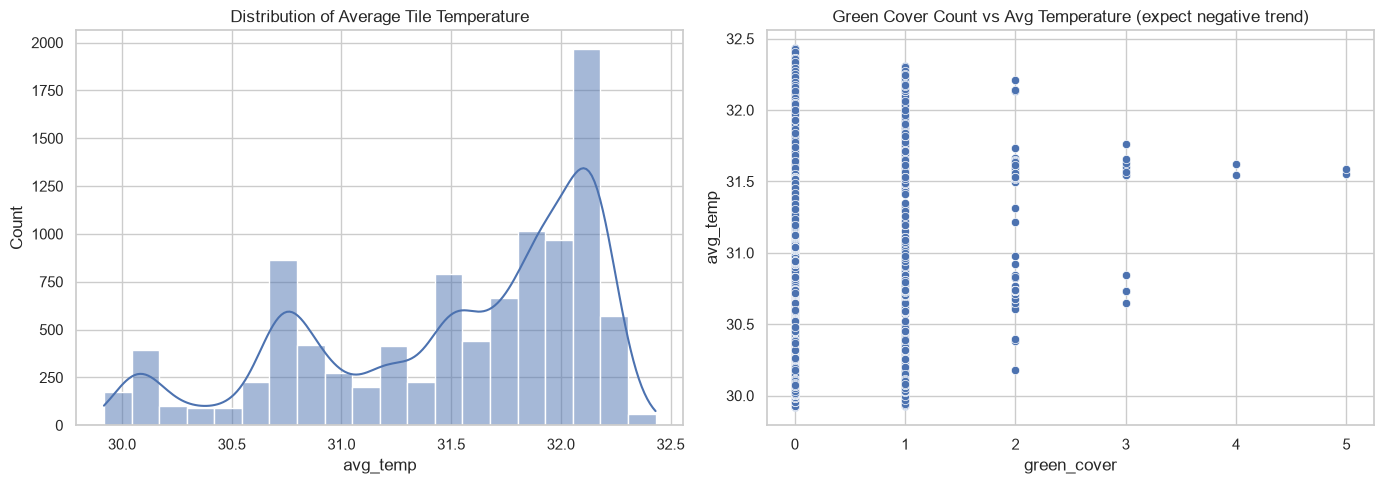

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(master_df["avg_temp"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Average Tile Temperature")

sns.scatterplot(data=master_df, x="green_cover", y="avg_temp", ax=axes[1])
axes[1].set_title("Green Cover Count vs Avg Temperature (expect negative trend)")

plt.tight_layout()
plt.show()

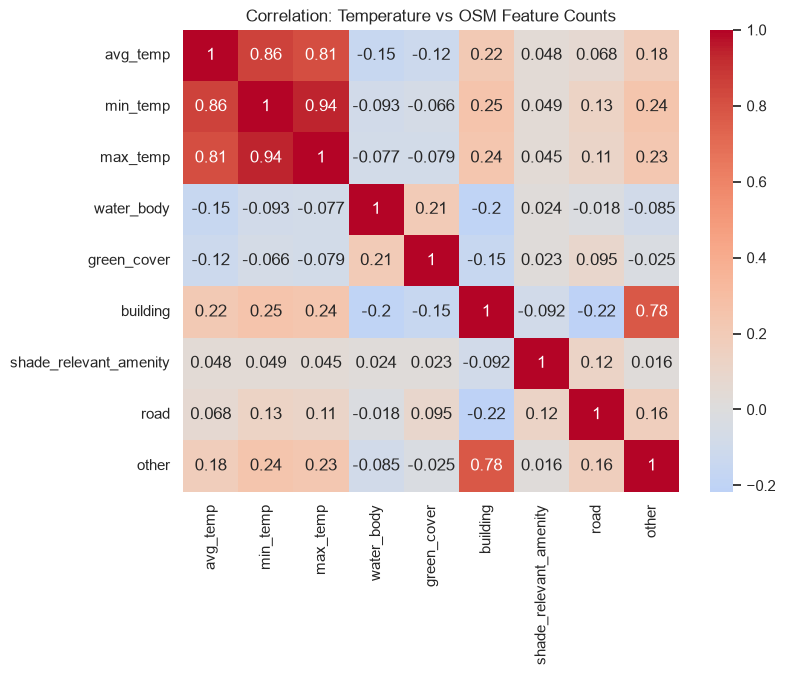

In [34]:
corr_cols = ["avg_temp", "min_temp", "max_temp"] + osm_cols_expected
corr = master_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation: Temperature vs OSM Feature Counts")
plt.show()

In [35]:
corr_check = master_df[["avg_temp","green_cover","water_body"]].corr()["avg_temp"]
print(corr_check)
assert corr_check["green_cover"] < 0, "green_cover correlation not negative — reconsider using it"

avg_temp       1.000000
green_cover   -0.121315
water_body    -0.151071
Name: avg_temp, dtype: float64


**What to look for here:**

- <font size=5 color='darkkhaki'>Does green_cover negatively correlate with avg_temp?

 Yes, the correlation between avg_temp and green_cover is -0.12, indicating a slight negative correlation. This validates its use in the risk formula, as higher green cover is associated with lower average temperatures.

- <font size=5 color='darkkhaki'>Does water_body show a cooling effect?

Yes, the correlation between avg_temp and water_body is -0.15, suggesting a cooling effect as higher presence of water bodies correlates with lower average temperatures.

- <font size=5 color='darkkhaki'>Are building counts positively correlated with temperature?

 Yes, the correlation between avg_temp and building counts is 0.22, which is a positive correlation. This supports the urban heat island effect, where higher building density is associated with higher temperatures.

- <font size=5 color='darkkhaki'> Any tiles with extreme temps but no OSM data nearby — flag as a data gap, not necessarily true risk.

The notebook's data cleaning steps (specifically master_df[osm_cols].fillna(0)) converted any missing OSM data counts to 0, ensuring all tiles have a value (even if zero) for OSM features. Therefore, after processing, there are no explicit 'nulls' for OSM data to flag as data gaps in the final master_df. The analysis assumes that a count of 0 implies an absence of the feature rather than a data gap.

---
##<font size=5 color='salmon'> 9. Feature Engineering

Create comparable 0–1 risk features while avoiding raw-count dominance.

### Improvements in this version
- Temperature uses both **average and maximum temperature**.
- `temp_range` captures the spread between minimum and maximum temperature.
- OSM counts are converted to **density per tile area** before normalization.
- Protective features are reversed so that **higher = higher risk contribution**.
- A data-coverage indicator is exported as confidence information, but it does **not** directly increase risk.


In [36]:
def min_max_normalize(series, cap_percentile=0.99):
    series = pd.to_numeric(series, errors="coerce").fillna(0)
    if series.max() == series.min():
        return pd.Series(0.0, index=series.index)
    lower = series.quantile(0.01)
    upper = series.quantile(cap_percentile)
    if upper <= lower:
        return pd.Series(0.0, index=series.index)
    capped = series.clip(lower=lower, upper=upper)
    return ((capped - lower) / (upper - lower)).clip(0, 1)

feat_df = master_df.copy()

# -------------------------
# A. HEAT EXPOSURE
# -------------------------
feat_df["temp_range"] = feat_df["max_temp"] - feat_df["min_temp"]
feat_df["norm_avg_temp"] = min_max_normalize(feat_df["avg_temp"])
feat_df["norm_max_temp"] = min_max_normalize(feat_df["max_temp"])
feat_df["norm_temp_range"] = min_max_normalize(feat_df["temp_range"])

# Combined heat exposure: average temperature is primary, peak temperature adds urgency.
feat_df["heat_exposure"] = (
    0.65 * feat_df["norm_avg_temp"] +
    0.35 * feat_df["norm_max_temp"]
)

# -------------------------
# B. DENSITY FEATURES
# -------------------------
for col in ["building", "green_cover", "water_body", "shade_relevant_amenity", "road"]:
    feat_df[f"{col}_density"] = feat_df[col] / feat_df["tile_area_km2"]

feat_df["norm_building_density"] = min_max_normalize(feat_df["building_density"])
feat_df["norm_road_density"] = min_max_normalize(feat_df["road_density"])

# -------------------------
# C. PROTECTIVE FEATURES → RISK DEFICITS
# -------------------------
# Log transform reduces the effect of a few unusually high OSM counts.
for raw, risk_name in [
    ("green_cover_density", "risk_green_cover"),
    ("water_body_density", "risk_water_body"),
    ("shade_relevant_amenity_density", "risk_shade"),
]:
    norm = min_max_normalize(np.log1p(feat_df[raw]))
    feat_df[risk_name] = 1 - norm

# -------------------------
# D. DATA CONFIDENCE
# -------------------------
# Confidence is informational only. Sparse OSM coverage should not automatically
# be interpreted as high heat risk.
coverage_p90 = max(feat_df["osm_feature_count"].quantile(0.90), 1)
feat_df["data_confidence"] = (
    feat_df["osm_feature_count"] / coverage_p90
).clip(0, 1)
feat_df["data_confidence_label"] = pd.cut(
    feat_df["data_confidence"],
    bins=[-0.01, 0.25, 0.60, 1.01],
    labels=["Low", "Medium", "High"]
)

feature_cols = [
    "heat_exposure",
    "norm_temp_range",
    "norm_building_density",
    "norm_road_density",
    "risk_green_cover",
    "risk_water_body",
    "risk_shade",
]

feat_df[["tile_id"] + feature_cols + ["data_confidence", "data_confidence_label"]].head()


,tile_id,heat_exposure,norm_temp_range,norm_building_density,norm_road_density,risk_green_cover,risk_water_body,risk_shade,data_confidence,data_confidence_label
0,0,0.959947,0.738584,0.103473,0.250266,1.0,1.0,1.0,0.379310,Medium
1,1,0.964676,0.748708,0.103475,0.000000,1.0,1.0,1.0,0.137931,Low
2,2,0.969222,0.758616,0.068984,0.125137,1.0,1.0,1.0,0.206897,Low
3,3,0.972154,0.767878,0.551882,0.156424,1.0,1.0,1.0,0.827586,High
4,4,0.973130,0.776278,0.517398,0.125141,1.0,1.0,1.0,0.784483,High


---
## <font size=5 color='salmon'>10. Risk Engine

Output: `risk_score` (0–100) + `risk_category`.

The weights below intentionally prevent average temperature from overwhelming all
other contextual factors. They are **transparent prototype weights** and should be
re-calibrated if historical health/outcome data becomes available.


In [37]:
# Transparent prototype weights.
# Total = 100%.
WEIGHTS = {
    "heat_exposure": 0.40,          # heat intensity + peak heat
    "norm_temp_range": 0.05,        # temperature spread / persistence proxy
    "norm_building_density": 0.15,  # built-up / urban heat context
    "norm_road_density": 0.05,      # impervious/traffic-context proxy
    "risk_green_cover": 0.15,       # lack of mapped green cover
    "risk_shade": 0.10,             # lack of shade-related amenities
    "risk_water_body": 0.10,       # lack of mapped cooling-water context
}
assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, "Weights must sum to 1.0"

def compute_risk_score(row, weights=WEIGHTS):
    score = sum(float(row[feat]) * weight for feat, weight in weights.items())
    return round(float(np.clip(score * 100, 0, 100)), 2)

feat_df["risk_score"] = feat_df.apply(compute_risk_score, axis=1)

def categorize_risk(score):
    if score < 25:
        return "Low"
    elif score < 50:
        return "Moderate"
    elif score < 75:
        return "High"
    return "Critical"

feat_df["risk_category"] = feat_df["risk_score"].apply(categorize_risk)

# Store each feature's actual weighted contribution. This makes the score explainable.
for feature, weight in WEIGHTS.items():
    feat_df[f"contrib_{feature}"] = feat_df[feature] * weight * 100

print("Risk category distribution:")
print(feat_df["risk_category"].value_counts().sort_index())
print("\nRisk score summary:")
print(feat_df["risk_score"].describe())

feat_df[["tile_id", "avg_temp", "max_temp", "risk_score", "risk_category"]].sort_values(
    "risk_score", ascending=False
).head(10)


Risk category distribution:
risk_category
Critical    4447
High        4303
Low          104
Moderate    1087
Name: count, dtype: int64

Risk score summary:
count    9941.000000
mean       68.509097
std        14.570667
min        10.160000
25%        60.440000
50%        73.250000
75%        79.150000
max        91.810000
Name: risk_score, dtype: float64


,tile_id,avg_temp,max_temp,risk_score,risk_category
3643,3643,31.9616,38.1790,91.81,Critical
3748,3748,31.9299,38.1448,91.48,Critical
3328,3328,31.9897,38.2090,91.28,Critical
181,181,32.0783,38.0806,91.16,Critical
1008,1008,32.0136,38.1624,90.71,Critical
1904,1904,32.2358,37.9454,90.66,Critical
3747,3747,31.9355,38.1492,90.48,Critical
3329,3329,31.9803,38.2026,90.34,Critical
3224,3224,31.9750,38.1967,90.23,Critical
1908,1908,32.2974,37.9559,90.11,Critical


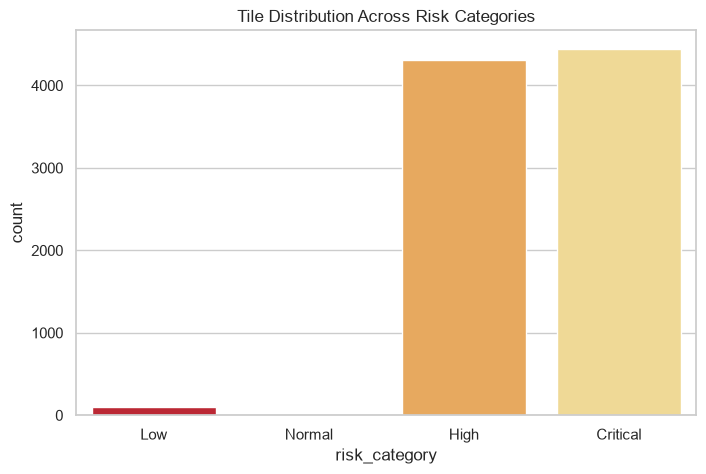

In [38]:
plt.figure(figsize=(8, 5))
sns.countplot(data=feat_df, x="risk_category", hue="risk_category", legend=False,
              order=["Low", "Normal", "High", "Critical"], palette="YlOrRd")
plt.title("Tile Distribution Across Risk Categories")
plt.show()

---
##<font size=5 color='salmon'> 11. Recommendation Engine

For every tile, identify the **top risk drivers** using their actual weighted
contributions. Return up to three actions instead of only one, so the dashboard
can explain both *why* an area is risky and *what can be done*.


In [39]:
RECOMMENDATION_TEXT = {
    "heat_exposure": "High heat exposure — prioritize shaded rest areas, cooling measures and worker heat alerts.",
    "norm_temp_range": "Large temperature range — strengthen time-sensitive monitoring and heat alerts.",
    "norm_building_density": "High built-up density — consider cool roofs, reflective surfaces and urban greening.",
    "norm_road_density": "High road density — prioritize shaded pedestrian/work routes and reduce exposed waiting areas.",
    "risk_green_cover": "Low mapped green cover — increase tree planting, pocket parks and green corridors.",
    "risk_shade": "Low mapped shade-related amenities — add shaded rest shelters and shaded work/waiting zones.",
    "risk_water_body": "Low mapped cooling-water context — prioritize hydration stations and accessible cooling points.",
}

DRIVER_LABELS = {
    "heat_exposure": "Heat exposure",
    "norm_temp_range": "Temperature range",
    "norm_building_density": "Building density",
    "norm_road_density": "Road density",
    "risk_green_cover": "Green-cover deficit",
    "risk_shade": "Shade deficit",
    "risk_water_body": "Cooling-water deficit",
}

CONTRIBUTION_COLS = {feature: f"contrib_{feature}" for feature in WEIGHTS}

def get_recommendations(row, max_actions=3):
    # Contributions are already in risk-score points, so no z-score is needed.
    ranked = sorted(
        WEIGHTS.keys(),
        key=lambda f: row[CONTRIBUTION_COLS[f]],
        reverse=True
    )

    selected = ranked[:max_actions]
    drivers = [DRIVER_LABELS[f] for f in selected]
    actions = [RECOMMENDATION_TEXT[f] for f in selected]

    return pd.Series({
        "top_risk_driver": drivers[0],
        "top_risk_drivers": " | ".join(drivers),
        "recommendations": " | ".join(actions),
    })

feat_df[["top_risk_driver", "top_risk_drivers", "recommendations"]] = feat_df.apply(
    get_recommendations, axis=1
)

feat_df[[
    "tile_id", "risk_score", "risk_category",
    "top_risk_drivers", "recommendations"
]].sort_values("risk_score", ascending=False).head(10)


,tile_id,risk_score,risk_category,top_risk_drivers,recommendations
3643,3643,91.81,Critical,Heat exposure | Building density | Green-cover...,High heat exposure — prioritize shaded rest ar...
3748,3748,91.48,Critical,Heat exposure | Building density | Green-cover...,High heat exposure — prioritize shaded rest ar...
3328,3328,91.28,Critical,Heat exposure | Building density | Green-cover...,High heat exposure — prioritize shaded rest ar...
181,181,91.16,Critical,Heat exposure | Building density | Green-cover...,High heat exposure — prioritize shaded rest ar...
1008,1008,90.71,Critical,Heat exposure | Building density | Green-cover...,High heat exposure — prioritize shaded rest ar...
1904,1904,90.66,Critical,Heat exposure | Green-cover deficit | Building...,High heat exposure — prioritize shaded rest ar...
3747,3747,90.48,Critical,Heat exposure | Building density | Green-cover...,High heat exposure — prioritize shaded rest ar...
3329,3329,90.34,Critical,Heat exposure | Building density | Green-cover...,High heat exposure — prioritize shaded rest ar...
3224,3224,90.23,Critical,Heat exposure | Building density | Green-cover...,High heat exposure — prioritize shaded rest ar...
1908,1908,90.11,Critical,Heat exposure | Green-cover deficit | Building...,High heat exposure — prioritize shaded rest ar...


In [40]:
print(feat_df["top_risk_driver"].value_counts())

top_risk_driver
Heat exposure            8761
Green-cover deficit      1064
Shade deficit             112
Cooling-water deficit       2
Building density            2
Name: count, dtype: int64


---
## <font size=5 color='salmon'>12. Projected Risk Score ("What-If" Simulator)

Estimate how the score changes when an intervention reduces one risk contribution.
This is a transparent scenario simulator, **not a causal prediction model**.


In [41]:
def simulate_improvement(row, feature_to_improve, improvement_pct, weights=WEIGHTS):
    """Reduce one risk feature by improvement_pct and recompute the score."""
    if feature_to_improve not in weights:
        raise ValueError(f"Unknown feature: {feature_to_improve}")
    if not 0 <= improvement_pct <= 100:
        raise ValueError("improvement_pct must be between 0 and 100")

    simulated_row = row.copy()
    reduction_factor = 1 - (improvement_pct / 100)
    simulated_row[feature_to_improve] = (
        simulated_row[feature_to_improve] * reduction_factor
    )

    original_score = compute_risk_score(row, weights)
    projected_score = compute_risk_score(simulated_row, weights)
    delta = round(original_score - projected_score, 2)
    return original_score, projected_score, delta

# Example: highest-risk tile — simulate a 40% reduction in green-cover deficit.
example_tile = feat_df.sort_values("risk_score", ascending=False).iloc[0]
orig, projected, delta = simulate_improvement(
    example_tile, "risk_green_cover", improvement_pct=40
)

print(f"Tile {int(example_tile['tile_id'])}")
print(f"Original risk score:  {orig}")
print(f"Projected risk score: {projected}")
print(f"Improvement:          -{delta} points")


Tile 3643
Original risk score:  91.81
Projected risk score: 85.81
Improvement:          -6.0 points


---
## <font size=5 color='salmon'>13. Handoff: Export for Website Integration

Export one JSON object per tile. The frontend can use the polygon/coordinates from
the source data and these risk fields for map coloring, tile details, recommendations
and what-if interactions.


In [43]:
output_cols = [
    "tile_id", "centroid_lat", "centroid_lon",
    "avg_temp", "min_temp", "max_temp", "temp_range",
    "building", "green_cover", "water_body",
    "shade_relevant_amenity", "road",
    "building_density", "green_cover_density", "water_body_density",
    "shade_relevant_amenity_density", "road_density",
    "risk_score", "risk_category",
    "data_confidence", "data_confidence_label",
    "top_risk_driver", "top_risk_drivers", "recommendations",
]

export_df = feat_df[output_cols].copy()

# Convert pandas categorical values to JSON-safe strings.
export_df["data_confidence_label"] = export_df["data_confidence_label"].astype(str)
export_records = export_df.to_dict(orient="records")

with open(f"{BASE_DIR}/data/tile_risk_scores.json", "w") as f:
    json.dump(export_records, f, indent=2, allow_nan=False)

print(f"Exported {len(export_records)} tiles to {BASE_DIR}/data/tile_risk_scores.json")
export_df.head()


Exported 9941 tiles to E:\github\IsoTherm/data/tile_risk_scores.json


,tile_id,centroid_lat,centroid_lon,avg_temp,min_temp,max_temp,temp_range,building,green_cover,water_body,shade_relevant_amenity,road,building_density,green_cover_density,water_body_density,shade_relevant_amenity_density,road_density,risk_score,risk_category,data_confidence,data_confidence_label,top_risk_driver,top_risk_drivers,recommendations
0,0,29.694510,-95.394746,32.1751,25.6710,38.1996,12.5286,3.0,0.0,0.0,0.0,8.0,287.072894,0.0,0.0,0.0,765.527717,79.89,Critical,0.379310,Medium,Heat exposure,Heat exposure | Green-cover deficit | Shade de...,High heat exposure — prioritize shaded rest ar...
1,1,29.694529,-95.393713,32.1796,25.6781,38.2208,12.5427,3.0,0.0,0.0,0.0,0.0,287.077489,0.0,0.0,0.0,0.000000,78.88,Critical,0.137931,Low,Heat exposure,Heat exposure | Green-cover deficit | Shade de...,High heat exposure — prioritize shaded rest ar...
2,2,29.694547,-95.392679,32.1838,25.6849,38.2414,12.5565,2.0,0.0,0.0,0.0,4.0,191.388056,0.0,0.0,0.0,382.776113,79.22,Critical,0.206897,Low,Heat exposure,Heat exposure | Green-cover deficit | Shade de...,High heat exposure — prioritize shaded rest ar...
3,3,29.694566,-95.391645,32.1876,25.6912,38.2606,12.5694,16.0,0.0,0.0,0.0,5.0,1531.128961,0.0,0.0,0.0,478.477800,86.79,Critical,0.827586,High,Heat exposure,Heat exposure | Green-cover deficit | Shade de...,High heat exposure — prioritize shaded rest ar...
4,4,29.694585,-95.390612,32.1910,25.6969,38.2780,12.5811,15.0,0.0,0.0,0.0,4.0,1435.456381,0.0,0.0,0.0,382.788368,86.19,Critical,0.784483,High,Heat exposure,Heat exposure | Green-cover deficit | Shade de...,High heat exposure — prioritize shaded rest ar...


---

## <font size=5 color='salmon'>Executive Summary: Heat Risk & Outdoor Worker Safety Intelligence Platform</font>

<p style='color:#3366ff; font-size:16px;'>This notebook builds an interpretable, tile-level heat-risk intelligence pipeline. FortyGuard supplies heat tiles and OpenStreetMap supplies urban/contextual features. The system converts those inputs into normalized risk factors, a 0–100 risk score, risk categories, multiple targeted interventions, and an explainable what-if simulator for the frontend.</p>

### <font size=4 color='darkcyan'>Key Stages & Improvements:</font>

1. **Data Acquisition & Validation:** Loaded FortyGuard and OSM payloads from SQLite and checked metadata quality.
2. **Spatial Integration:** Flattened FortyGuard heat tiles, resolved OSM nodes/ways, and assigned OSM features to tiles.
3. **Feature Engineering:** Added peak-temperature and temperature-range features and converted raw OSM counts into per-tile density indicators.
4. **Risk Engine:** Uses transparent prototype weights across heat exposure, built environment, roads, green-cover deficit, shade deficit and cooling-water context.
5. **Explainability:** Stores the weighted contribution of every risk factor, making each score auditable.
6. **Recommendation Engine:** Returns the top three risk drivers and corresponding intervention actions.
7. **Data Confidence:** Reports OSM coverage confidence separately so missing OSM data is not silently treated as high risk.
8. **What-If Simulator:** Estimates score reduction under a hypothetical intervention without retraining a model.
9. **Frontend Handoff:** Exports a clean `tile_risk_scores.json` containing the fields required by the web dashboard/API.

### <font size=4 color='darkcyan'>Important Prototype Limitation</font>

The current risk weights and categories are **heuristic**. They are intended to make the hackathon prototype transparent and actionable. If historical heat-health, worker exposure, or validated vulnerability labels become available, the weights and thresholds should be calibrated against that evidence rather than treated as scientifically validated.

### <font size=4 color='darkcyan'>Next Step</font>

The web dashboard should visualize the tile-level risk map and, when a tile is selected, show its heat exposure, contextual drivers, confidence, recommended interventions, and a what-if scenario.
